# Performance by Genomic Region

Analyze model performance (per-CpG-site R², Pearson, MSE) stratified by genomic annotation
(promoter / UTR / exon / intron / intergenic, etc.) for the test CpG sites in the model output.

Adapted from `11zannotateregions_dmr.ipynb`.

## 1. Imports

In [1]:
import glob
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pybedtools import BedTool

%matplotlib inline

## 2. Configuration

In [2]:
# Test CpG sites come from the *_signals.csv files inside the model's val set output.
# Pick a single signal CSV to analyze (change as needed).
OUTPUT_DIR = Path("/data1st1/junyi/output/mmllm/AMY_MC/")

# Pattern matches e.g. output/AMY_MC/cCRE_cpg/2026-06-30-15-38-58_*_80137.csv
SIGNAL_PATTERN = str(OUTPUT_DIR / "cCRE_cpg" / "*results*.csv")
# We only want the val set's per-CpG predictions; restrict to the largest sample_size CSVs:
signal_files = sorted(glob.glob(SIGNAL_PATTERN))
print(f"Found {len(signal_files)} signal CSV file(s)")
for f in signal_files:
    print(" ", f)

Found 4 signal CSV file(s)
  /data1st1/junyi/output/mmllm/AMY_MC/cCRE_cpg/2026-06-30-10-59-52_m5c_query_sequence_atac_crosshyena_modelb_cross_hyena_results.csv
  /data1st1/junyi/output/mmllm/AMY_MC/cCRE_cpg/2026-06-30-15-38-58_m5c_query_sequence_atac_crosshyena_modelb_cross_hyena_results.csv
  /data1st1/junyi/output/mmllm/AMY_MC/cCRE_cpg/2026-07-13-16-21-08_m5c_query_sequence_atac_crosshyena_modelb_cross_hyena_results.csv
  /data1st1/junyi/output/mmllm/AMY_MC/cCRE_cpg/2026-07-14-14-50-08_m5c_query_sequence_atac_crosshyena_modelb_cross_hyena_results.csv


In [3]:
# Annotation BED files (must contain chr/start/end at minimum).
ANNO_DIR = "/data2st1/junyi/generegion_vM23"

ANNOTATIONS = {
    "promoter":    f"{ANNO_DIR}/promoter2k.bed",
    "UTR":         f"{ANNO_DIR}/UTR.bed",
    "exon":        f"{ANNO_DIR}/exon_selected.bed",
    "intron":      f"{ANNO_DIR}/intron_selected.bed",
    "intergenic":  f"{ANNO_DIR}/intergenic.bed",
    "cCRE":        f"{ANNO_DIR}/mm10-cCREs.bed",
    "LINE":        f"{ANNO_DIR}/LINE.bed",
    "SINE":        f"{ANNO_DIR}/SINE.bed",
    "LTR":         f"{ANNO_DIR}/LTR.bed",
}

## 3. Load per-CpG predictions

Each row of the signal CSV is one CpG site. We keep only sites where `mask == 1`,
i.e. CpG positions actually used by the model.

In [4]:
signal_files = ['/data1st1/junyi/output/mmllm/AMY_MC/cCRE_cpg/2026-07-14-14-50-08_m5c_query_sequence_atac_crosshyena_modelb_cross_hyena_80137.csv']

In [5]:
def load_signal_csv(path):
    df = pd.read_csv(path)
    # Convert CpG sites to BED-style chr/start/end (genomic_position is 1-based)
    df["start"] = df["genomic_position"] - 1
    df["end"] = df["genomic_position"]
    # Keep only masked (CpG) positions for evaluation
    df = df[df["mask"] > 0].copy()
    return df

dfs = {os.path.basename(f): load_signal_csv(f) for f in signal_files}
for name, df in dfs.items():
    print(f"{name}: {len(df):,} CpG sites")

2026-07-14-14-50-08_m5c_query_sequence_atac_crosshyena_modelb_cross_hyena_80137.csv: 4,699,197 CpG sites


In [6]:
dfs[name]

,region_idx,original_idx,strand_view,chr,start_expanded,end_expanded,position_idx,genomic_position,base,predicted_signal,true_signal,mask,start,end
210,0,63592,+,chr15,38065752,38082135,210,38065962,C,32.043537,33.968254,1.0,38065961,38065962
240,0,63592,+,chr15,38065752,38082135,240,38065992,C,34.318649,55.555557,1.0,38065991,38065992
313,0,63592,+,chr15,38065752,38082135,313,38066065,C,20.530949,31.851852,1.0,38066064,38066065
325,0,63592,+,chr15,38065752,38082135,325,38066077,C,53.246655,42.121212,1.0,38066076,38066077
346,0,63592,+,chr15,38065752,38082135,346,38066098,C,26.834126,42.222225,1.0,38066097,38066098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271073124,16544,80136,+,chrY,90825130,90841513,16228,90841358,C,13.477686,0.000000,1.0,90841357,90841358
271073131,16544,80136,+,chrY,90825130,90841513,16235,90841365,C,11.850138,31.746035,1.0,90841364,90841365
271073148,16544,80136,+,chrY,90825130,90841513,16252,90841382,C,2.963770,6.666667,1.0,90841381,90841382
271073185,16544,80136,+,chrY,90825130,90841513,16289,90841419,C,18.474548,6.666667,1.0,90841418,90841419


## 4. Intersect with annotation BEDs

For each annotation, mark each CpG site as belonging or not (True/False).

In [7]:
def intersect_bed_files(bed_file1, bed_file2):
    """Intersect bed_file1 (CpG sites) with bed_file2 (annotation)."""
    bed1 = BedTool(bed_file1)
    bed2 = BedTool(bed_file2)
    merged = bed1.intersect(bed2, wa=True, wb=True)
    non_overlapping = bed1.subtract(bed2)
    return merged, non_overlapping


def annotate_cpg_sites(df_cpg: pd.DataFrame, annotations: dict) -> pd.DataFrame:
    """Add boolean columns for each annotation.

    df_cpg must contain columns: chr, start, end.
    """
    # Write CpG sites to a temporary BED
    tmp_bed = df_cpg[["chr", "start", "end"]].drop_duplicates()
    tmp_bed_path = "/tmp/_cpg_sites.bed"
    tmp_bed.to_csv(tmp_bed_path, sep="\t", index=False, header=False)

    # For each annotation, build a set of (chr,start,end) that intersect
    annotated_keys = {}
    for name, path in annotations.items():
        if not os.path.exists(path):
            print(f"WARNING: annotation BED not found: {path}")
            annotated_keys[name] = set()
            continue
        print(f"  intersecting with {name} ({path}) ...", flush=True)
        try:
            merged, _ = intersect_bed_files(tmp_bed_path, path)
            merged_df = merged.to_dataframe(dtype=str).iloc[:, :3]
        except Exception as exc:
            print(f"  ERROR on {name}: {exc!r}; treating as empty.")
            annotated_keys[name] = set()
            continue
        merged_df.columns = ["chr", "start", "end"]
        merged_df["key"] = (
            merged_df["chr"].astype(str) + ":" +
            merged_df["start"].astype(str) + "-" +
            merged_df["end"].astype(str)
        )
        annotated_keys[name] = set(merged_df["key"].tolist())
        print(f"    -> {len(annotated_keys[name]):,} CpG sites hit {name}", flush=True)

    # Build key per row of df_cpg
    df = df_cpg.copy()
    df["key"] = (
        df["chr"].astype(str) + ":" +
        df["start"].astype(str) + "-" +
        df["end"].astype(str)
    )
    for name in annotations:
        df[f"in_{name}"] = df["key"].isin(annotated_keys.get(name, set()))
    df = df.drop(columns=["key"])
    return df


# Annotate each loaded dataframe
annotated_dfs = {name: annotate_cpg_sites(df, ANNOTATIONS) for name, df in dfs.items()}
print("Annotated:")
for name, df in annotated_dfs.items():
    print(f"  {name}: {df.shape}, in_promoter={df['in_promoter'].sum():,}")

  intersecting with promoter (/data2st1/junyi/generegion_vM23/promoter2k.bed) ...
    -> 166,108 CpG sites hit promoter
  intersecting with UTR (/data2st1/junyi/generegion_vM23/UTR.bed) ...


***** WARNING: File /data2st1/junyi/generegion_vM23/UTR.bed has inconsistent naming convention for record:
KZ289081.1	123732	123914	.	+	Slfn2	ENSMUSG00000116022.1	basic

***** WARNING: File /data2st1/junyi/generegion_vM23/UTR.bed has inconsistent naming convention for record:
KZ289081.1	123732	123914	.	+	Slfn2	ENSMUSG00000116022.1	basic

***** WARNING: File /data2st1/junyi/generegion_vM23/UTR.bed has inconsistent naming convention for record:
KZ289081.1	123732	123914	.	+	Slfn2	ENSMUSG00000116022.1	basic

***** WARNING: File /data2st1/junyi/generegion_vM23/UTR.bed has inconsistent naming convention for record:
KZ289081.1	123732	123914	.	+	Slfn2	ENSMUSG00000116022.1	basic



    -> 108,165 CpG sites hit UTR
  intersecting with exon (/data2st1/junyi/generegion_vM23/exon_selected.bed) ...
    -> 257,821 CpG sites hit exon
  intersecting with intron (/data2st1/junyi/generegion_vM23/intron_selected.bed) ...
    -> 482,820 CpG sites hit intron
  intersecting with intergenic (/data2st1/junyi/generegion_vM23/intergenic.bed) ...


***** WARNING: File /data2st1/junyi/generegion_vM23/intergenic.bed has inconsistent naming convention for record:
KZ289080.1	8460	14905	.	.	intergenic

***** WARNING: File /data2st1/junyi/generegion_vM23/intergenic.bed has inconsistent naming convention for record:
KZ289080.1	8460	14905	.	.	intergenic

***** WARNING: File /data2st1/junyi/generegion_vM23/intergenic.bed has inconsistent naming convention for record:
KZ289080.1	8460	14905	.	.	intergenic

***** WARNING: File /data2st1/junyi/generegion_vM23/intergenic.bed has inconsistent naming convention for record:
KZ289080.1	8460	14905	.	.	intergenic



    -> 380,436 CpG sites hit intergenic
  intersecting with cCRE (/data2st1/junyi/generegion_vM23/mm10-cCREs.bed) ...
    -> 257,070 CpG sites hit cCRE
  intersecting with LINE (/data2st1/junyi/generegion_vM23/LINE.bed) ...
    -> 22 CpG sites hit LINE
  intersecting with SINE (/data2st1/junyi/generegion_vM23/SINE.bed) ...
    -> 6,699 CpG sites hit SINE
  intersecting with LTR (/data2st1/junyi/generegion_vM23/LTR.bed) ...
    -> 18,253 CpG sites hit LTR
Annotated:
  2026-07-14-14-50-08_m5c_query_sequence_atac_crosshyena_modelb_cross_hyena_80137.csv: (4699197, 23), in_promoter=1,048,488


## 5. Assign primary region to each CpG site (priority-based)

Adapted from `get_proity_region()` in the reference notebook: higher priority overrides lower.

In [8]:
PRIORITY = ["promoter", "UTR", "exon", "intron", "intergenic"]


def assign_primary_region(df: pd.DataFrame, priority: list = PRIORITY) -> pd.DataFrame:
    df = df.copy()
    df["primary_region"] = priority[-1]  # default = lowest priority
    for region in priority[::-1]:
        col = f"in_{region}"
        if col in df.columns:
            df.loc[df[col], "primary_region"] = region
    return df


annotated_dfs = {
    name: assign_primary_region(df) for name, df in annotated_dfs.items()
}
for name, df in annotated_dfs.items():
    print(f"\n{name}: primary_region distribution")
    print(df["primary_region"].value_counts())


2026-07-14-14-50-08_m5c_query_sequence_atac_crosshyena_modelb_cross_hyena_80137.csv: primary_region distribution
primary_region
intron        1483117
promoter      1048488
intergenic    1032189
exon           839802
UTR            295601
Name: count, dtype: int64


## 6. Compute per-region performance metrics

For each primary_region, compute Pearson r, R² and MSE on the CpG positions within it.

In [9]:
def per_region_metrics(df: pd.DataFrame, region_col: str = "primary_region") -> pd.DataFrame:
    """Compute per-region regression metrics on (true_signal, predicted_signal)."""
    rows = []
    for region, sub in df.groupby(region_col):
        y = sub["true_signal"].values
        yhat = sub["predicted_signal"].values
        n = len(sub)
        if n < 2:
            rows.append({
                "primary_region": region,
                "n_sites": n,
                "mse": np.nan,
                "r2": np.nan,
                "pearson": np.nan,
            })
            continue
        mse = float(np.mean((y - yhat) ** 2))
        ss_res = float(np.sum((y - yhat) ** 2))
        ss_tot = float(np.sum((y - y.mean()) ** 2)) + 1e-12
        r2 = 1.0 - ss_res / ss_tot
        if np.std(y) > 0 and np.std(yhat) > 0:
            pearson = float(np.corrcoef(y, yhat)[0, 1])
        else:
            pearson = float("nan")
        rows.append({
            "primary_region": region,
            "n_sites": n,
            "mse": mse,
            "r2": r2,
            "pearson": pearson,
        })
    return pd.DataFrame(rows).sort_values("n_sites", ascending=False)


metrics_by_file = {
    name: per_region_metrics(df) for name, df in annotated_dfs.items()
}

In [10]:
for name, m in metrics_by_file.items():
    print(f"\n=== {name} ===")
    display(m)


=== 2026-07-14-14-50-08_m5c_query_sequence_atac_crosshyena_modelb_cross_hyena_80137.csv ===


,primary_region,n_sites,mse,r2,pearson
3,intron,1483117,142.357782,0.666731,0.817114
4,promoter,1048488,48.329974,0.715301,0.846247
2,intergenic,1032189,147.328707,0.589743,0.770011
1,exon,839802,111.422891,0.659089,0.813507
0,UTR,295601,97.434109,0.697499,0.835503


## 7. Visualize: Pearson r by region

In [11]:
def radar_plot(metrics_by_file, metric_col, title, out_path,
               regions=None,
               vmin=0.3, vmax=0.95, step=0.1):
    """Draw a radar (spider) chart of `metric_col` across `regions`.

    One axis per region. One polygon per signal CSV.

    The radial axis is clamped to [vmin, vmax] so that small differences
    between models are amplified. Values outside the range are clipped.
    """
    if regions is None:
        regions = PRIORITY

    # Collect values per (source, region) with regions in the canonical order.
    # `metrics_by_file` may be keyed either by `primary_region` (functional)
    # or by `region` (generic helper) — accept whichever is present.
    sources = list(metrics_by_file.keys())
    plot_rows = []
    for src, m in metrics_by_file.items():
        if "primary_region" in m.columns:
            m_indexed = m.set_index("primary_region")
        elif "region" in m.columns:
            m_indexed = m.set_index("region")
        else:
            raise KeyError(
                f"metrics DataFrame for {src} must have a `primary_region` or "
                f"`region` column; got {list(m.columns)}"
            )
        row = {"source": src}
        for r in regions:
            row[r] = float(m_indexed[metric_col].get(r, np.nan))
        plot_rows.append(row)
    plot_df = pd.DataFrame(plot_rows).set_index("source")

    # Close the polygon by repeating the first region at the end.
    angles = np.linspace(0, 2 * np.pi, len(regions), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(
        figsize=(7, 7),
        subplot_kw=dict(polar=True),
    )
    cmap = plt.get_cmap("viridis")
    colors = [cmap(i / max(1, len(sources) - 1)) for i in range(len(sources))]

    # Clip values to [vmin, vmax] so the radial contrast is strong,
    # but keep the unclipped value as text for each vertex.
    for color, (src, row) in zip(colors, plot_df.iterrows()):
        raw_values = [row[r] for r in regions]
        clipped = [min(max(v, vmin), vmax) for v in raw_values]
        clipped += clipped[:1]
        ax.plot(angles, clipped, color=color, linewidth=2.5, label=src)
        ax.fill(angles, clipped, color=color, alpha=0.18)
        # Annotate each vertex with its raw value for reference.
        for ang, v in zip(angles[:-1], raw_values):
            ax.text(ang, vmax + 0.02,
                    f"{v:.2f}", color=color, fontsize=8,
                    ha="center", va="center")

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(regions, fontsize=11)
    ax.set_ylim(vmin, vmax)
    yticks = np.round(np.arange(vmin, vmax + 1e-9, step), 2)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{v:.2f}" for v in yticks], fontsize=8)
    ax.set_rlabel_position(90)
    ax.set_title(f"{title}\n(clipped to [{vmin:.2f}, {vmax:.2f}])", pad=22)
    ax.legend(loc="upper right", bbox_to_anchor=(1.30, 1.10), fontsize=8)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


In [12]:
metrics_by_file

{'2026-07-14-14-50-08_m5c_query_sequence_atac_crosshyena_modelb_cross_hyena_80137.csv':   primary_region  n_sites         mse        r2   pearson
 3         intron  1483117  142.357782  0.666731  0.817114
 4       promoter  1048488   48.329974  0.715301  0.846247
 2     intergenic  1032189  147.328707  0.589743  0.770011
 1           exon   839802  111.422891  0.659089  0.813507
 0            UTR   295601   97.434109  0.697499  0.835503}

## 8. Visualize: R² by region

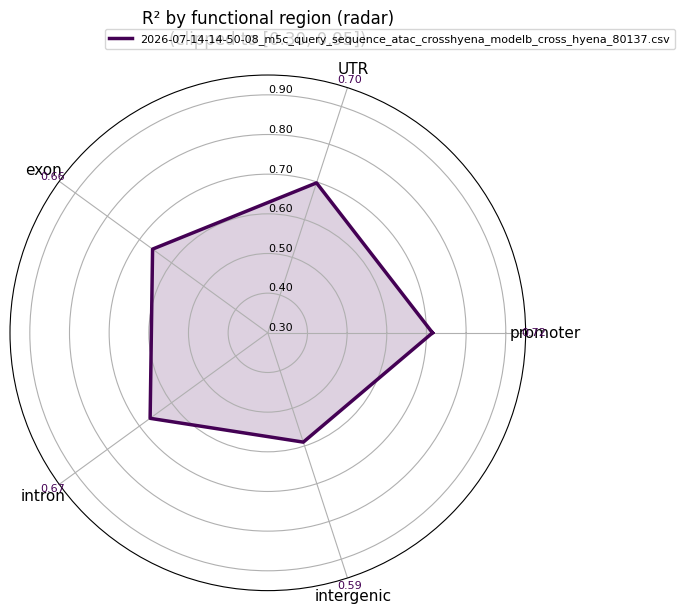

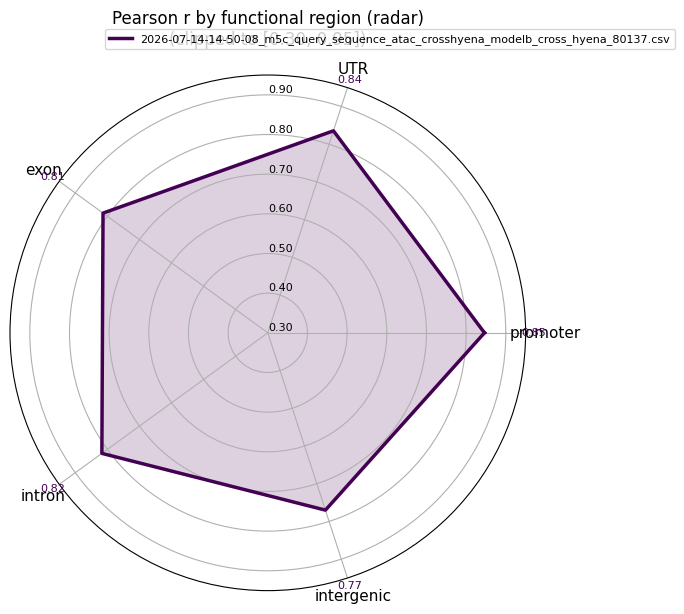

In [13]:
radar_plot(
    metrics_by_file,
    metric_col="r2",
    title="R² by functional region (radar)",
    out_path="output/per_region_r2_radar.png",
)

radar_plot(
    metrics_by_file,
    metric_col="pearson",
    title="Pearson r by functional region (radar)",
    out_path="output/per_region_pearson_radar.png",
)

## 9. Repeat-element hierarchy radar

Compute per-region metrics with a *repeat-element* priority (cCRE > LINE > SINE > LTR),
then plot Pearson r and R² as radar charts.


In [14]:
REPEAT_PRIORITY = ["cCRE", "LINE", "SINE", "LTR"]
MIN_REPEAT_SITES = 1000  # skip under-represented repeats (e.g. LINE has ~100 CpG sites)

def assign_repeat_region(df: pd.DataFrame, priority: list = REPEAT_PRIORITY) -> pd.DataFrame:
    df = df.copy()
    df["repeat_region"] = priority[-1]
    for region in priority[::-1]:
        col = f"in_{region}"
        if col in df.columns:
            df.loc[df[col], "repeat_region"] = region
    return df

def per_region_metrics_generic(df: pd.DataFrame, region_col: str) -> pd.DataFrame:
    rows = []
    for region, sub in df.groupby(region_col):
        y = sub["true_signal"].values
        yhat = sub["predicted_signal"].values
        n = len(sub)
        if n < 2:
            rows.append({"region": region, "n_sites": n,
                         "mse": np.nan, "r2": np.nan, "pearson": np.nan})
            continue
        mse = float(np.mean((y - yhat) ** 2))
        ss_res = float(np.sum((y - yhat) ** 2))
        ss_tot = float(np.sum((y - y.mean()) ** 2)) + 1e-12
        r2 = 1.0 - ss_res / ss_tot
        if np.std(y) > 0 and np.std(yhat) > 0:
            pearson = float(np.corrcoef(y, yhat)[0, 1])
        else:
            pearson = float("nan")
        rows.append({"region": region, "n_sites": n,
                     "mse": mse, "r2": r2, "pearson": pearson})
    return pd.DataFrame(rows).sort_values("n_sites", ascending=False)

repeat_metrics_by_file = {
    name: per_region_metrics_generic(
        assign_repeat_region(df), region_col="repeat_region"
    )
    for name, df in annotated_dfs.items()
}
for name, m in repeat_metrics_by_file.items():
    print(f"\n=== {name} (repeat hierarchy) ===")
    display(m)

# Determine which repeat regions have enough sites to plot.
_all_repeat = pd.concat(repeat_metrics_by_file.values(), ignore_index=True)
_repeat_regions_with_data = sorted(
    [r for r in REPEAT_PRIORITY
     if (int(_all_repeat.loc[_all_repeat["region"] == r, "n_sites"].sum()) >= MIN_REPEAT_SITES)]
)
print(f"\nPlotting repeat regions with >= {MIN_REPEAT_SITES} sites: {_repeat_regions_with_data}")

radar_plot(
    {name: m.set_index("region") for name, m in repeat_metrics_by_file.items()},
    metric_col="pearson",
    title="Pearson r by repeat-element region (radar)",
    out_path="output/per_repeat_pearson_radar.png",
    regions=_repeat_regions_with_data or REPEAT_PRIORITY,
    vmin=0.3, vmax=0.95, step=0.1,
)

radar_plot(
    {name: m.set_index("region") for name, m in repeat_metrics_by_file.items()},
    metric_col="r2",
    title="R\u00b2 by repeat-element region (radar)",
    out_path="output/per_repeat_r2_radar.png",
    regions=_repeat_regions_with_data or REPEAT_PRIORITY,
    vmin=0.3, vmax=0.95, step=0.1,
)



=== 2026-07-14-14-50-08_m5c_query_sequence_atac_crosshyena_modelb_cross_hyena_80137.csv (repeat hierarchy) ===


,region,n_sites,mse,r2,pearson
1,LTR,3068267,155.935797,0.624483,0.790586
3,cCRE,1607043,32.673705,0.704136,0.841010
2,SINE,23823,221.309706,0.557293,0.747419
0,LINE,64,305.222465,0.221552,0.509017



Plotting repeat regions with >= 1000 sites: ['LTR', 'SINE', 'cCRE']


KeyError: "metrics DataFrame for 2026-07-14-14-50-08_m5c_query_sequence_atac_crosshyena_modelb_cross_hyena_80137.csv must have a `primary_region` or `region` column; got ['n_sites', 'mse', 'r2', 'pearson']"

## 10. cCRE sub-type radar

The cCRE BED has a 6th column with multiple comma-separated sub-types
(`dELS`, `pELS`, `PLS`, `DNase-H3K4me3`, each optionally with `CTCF-bound`).
Intersect CpG sites with each sub-type independently and plot per-sub-type metrics.


In [ ]:
import re
from collections import defaultdict

CCRE_BED = ANNOTATIONS["cCRE"]
MIN_CCRE_SITES = 1000

# Parse all (chr, start, end, sub-types-set) from the cCRE BED.
_ccre_records = []
_ccre_types_seen = set()
with open(CCRE_BED) as _f:
    for _line in _f:
        _cols = _line.rstrip("\n").split("\t")
        if len(_cols) < 6:
            continue
        _types = set(t.strip() for t in _cols[5].split(",") if t.strip())
        _ccre_records.append((_cols[0], int(_cols[1]), int(_cols[2]), _types))
        _ccre_types_seen.update(_types)
print(f"Loaded {len(_ccre_records):,} cCRE records covering sub-types: {sorted(_ccre_types_seen)}")

# Build one BED per sub-type and intersect CpG sites with it.
_tmp_cpg = "/tmp/_cpg_sites.bed"
_ccre_intersect_counts = {}
_ccre_masks = {}
for _t in sorted(_ccre_types_seen):
    _safe = _t.replace(" ", "_").replace("-", "_").replace(",", "_")
    _bed = f"/tmp/_ccre_{_safe}.bed"
    with open(_bed, "w") as _out:
        for _chr, _s, _e, _types in _ccre_records:
            if _t in _types:
                _out.write(f"{_chr}\t{_s}\t{_e}\n")
    try:
        _merged = BedTool(_tmp_cpg).intersect(BedTool(_bed), wa=True, wb=False)
        _df = _merged.to_dataframe(dtype=str).iloc[:, :3]
        _df.columns = ["chr", "start", "end"]
        _df["key"] = (_df["chr"] + ":" + _df["start"] + "-" + _df["end"])
        _ccre_masks[_t] = set(_df["key"].tolist())
        _ccre_intersect_counts[_t] = len(_ccre_masks[_t])
    except Exception as _exc:
        print(f"  ERROR on sub-type {_t}: {_exc!r}; treating as empty.")
        _ccre_masks[_t] = set()
        _ccre_intersect_counts[_t] = 0
    print(f"  {_t:30s} -> {_ccre_intersect_counts[_t]:>10,} CpG sites")

# Pick sub-types with enough sites to plot.
_ccre_regions_with_data = sorted(
    [t for t, n in _ccre_intersect_counts.items() if n >= MIN_CCRE_SITES]
)
print(f"\nPlotting cCRE sub-types with >= {MIN_CCRE_SITES} sites: {_ccre_regions_with_data}")

# Build per-sub-type metrics for each annotated df.
ccre_metrics_by_file = {}
for _name, _df in annotated_dfs.items():
    _df2 = _df.copy()
    _df2["key"] = (_df2["chr"].astype(str) + ":" +
                    _df2["start"].astype(str) + "-" +
                    _df2["end"].astype(str))
    rows = []
    for _t in sorted(_ccre_types_seen):
        if _t not in _ccre_regions_with_data:
            continue
        _mask = _df2["key"].isin(_ccre_masks[_t])
        _sub = _df2[_mask]
        _y = _sub["true_signal"].values
        _yhat = _sub["predicted_signal"].values
        _n = len(_sub)
        if _n < 2:
            rows.append({"region": _t, "n_sites": _n,
                         "mse": np.nan, "r2": np.nan, "pearson": np.nan})
            continue
        _mse = float(np.mean((_y - _yhat) ** 2))
        _ss_res = float(np.sum((_y - _yhat) ** 2))
        _ss_tot = float(np.sum((_y - _y.mean()) ** 2)) + 1e-12
        _r2 = 1.0 - _ss_res / _ss_tot
        _pearson = float(np.corrcoef(_y, _yhat)[0, 1]) if np.std(_y) > 0 and np.std(_yhat) > 0 else float("nan")
        rows.append({"region": _t, "n_sites": _n,
                     "mse": _mse, "r2": _r2, "pearson": _pearson})
    ccre_metrics_by_file[_name] = pd.DataFrame(rows).sort_values("n_sites", ascending=False)

for _name, _m in ccre_metrics_by_file.items():
    print(f"\n=== {_name} (cCRE sub-types) ===")
    display(_m)

if _ccre_regions_with_data:
    radar_plot(
        {n: m.set_index("region") for n, m in ccre_metrics_by_file.items()},
        metric_col="pearson",
        title="Pearson r by cCRE sub-type (radar)",
        out_path="output/per_ccre_pearson_radar.png",
        regions=_ccre_regions_with_data,
        vmin=0.3, vmax=0.95, step=0.1,
    )
    radar_plot(
        {n: m.set_index("region") for n, m in ccre_metrics_by_file.items()},
        metric_col="r2",
        title="R\u00b2 by cCRE sub-type (radar)",
        out_path="output/per_ccre_r2_radar.png",
        regions=_ccre_regions_with_data,
        vmin=0.3, vmax=0.95, step=0.1,
    )
else:
    print("No cCRE sub-type has enough sites to plot.")


Loaded 368,121 cCRE records covering sub-types: ['CTCF-bound', 'CTCF-only', 'DNase-H3K4me3', 'PLS', 'dELS', 'pELS']
  CTCF-bound                     ->    110,096 CpG sites
  CTCF-only                      ->      2,823 CpG sites
  DNase-H3K4me3                  ->      8,826 CpG sites
  PLS                            ->      5,186 CpG sites
  dELS                           ->    209,564 CpG sites
  pELS                           ->     30,671 CpG sites

Plotting cCRE sub-types with >= 1000 sites: ['CTCF-bound', 'CTCF-only', 'DNase-H3K4me3', 'PLS', 'dELS', 'pELS']

=== 2026-07-14-14-50-08_m5c_query_sequence_atac_crosshyena_modelb_cross_hyena_80137.csv (cCRE sub-types) ===


,region,n_sites,mse,r2,pearson
4,dELS,1304222,30.314817,0.714216,0.846467
0,CTCF-bound,695019,14.078411,0.653000,0.812971
5,pELS,195939,37.364302,0.689348,0.833012
2,DNase-H3K4me3,64188,58.047228,0.605035,0.792259
3,PLS,31299,20.923463,0.737765,0.859280
1,CTCF-only,11395,111.351857,0.554159,0.751841


KeyError: "metrics DataFrame for 2026-07-14-14-50-08_m5c_query_sequence_atac_crosshyena_modelb_cross_hyena_80137.csv must have a `primary_region` or `region` column; got ['n_sites', 'mse', 'r2', 'pearson']"

## 9. Save per-region metrics to CSV

In [ ]:
out_dir = Path("output/per_region_analysis")
out_dir.mkdir(parents=True, exist_ok=True)
for name, m in metrics_by_file.items():
    stem = Path(name).stem
    out_path = out_dir / f"{stem}_per_region_metrics.csv"
    m.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")

    # Save annotated full df for downstream exploration
    annotated_out_path = out_dir / f"{stem}_annotated_cpgs.csv"
    annotated_dfs[name].to_csv(annotated_out_path, index=False)
    print(f"Saved: {annotated_out_path}")

## 10. (Optional) Cross-tissue comparison

If multiple output folders are available (e.g. AMY_MC, HIP_MC, PFC_MC), compare
Pearson r side by side.

In [ ]:
if len(metrics_by_file) >= 2:
    combined = pd.concat(
        [
            m.assign(source=name)
            for name, m in metrics_by_file.items()
        ],
        ignore_index=True,
    )
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=combined, x="primary_region", y="pearson", hue="source", ax=ax)
    ax.set_title("Pearson r by region and run")
    ax.set_ylim(-0.1, 1.0)
    plt.tight_layout()
    plt.savefig("output/per_region_pearson_combined.png", dpi=150, bbox_inches="tight")
    plt.show()
    combined.to_csv(out_dir / "combined_per_region_metrics.csv", index=False)
else:
    print("Only one signal CSV found — add more to compare across runs.")